In [2]:
import numpy as np
import pickle
import torch
# import lightgbm as lgb
from torchmetrics.regression import MeanSquaredError
from torchmetrics.functional.image import peak_signal_noise_ratio
from torchmetrics.functional.image import structural_similarity_index_measure

In [ ]:
# # Train/app/data/processed/cmip6-cmip6/test_ens_data.pkl
# with open('/app/data/processed/cmip6-cmip6/train_ens_data_42.pkl', 'rb') as f:
#     train_data_42 = pickle.load(f)

# with open('/app/data/processed/cmip6-cmip6/train_ens_data_123.pkl', 'rb') as f:
#     train_data_123 = pickle.load(f)

# with open('/app/data/processed/cmip6-cmip6/train_ens_data_777.pkl', 'rb') as f:
#     train_data_777 = pickle.load(f)

# with open('/app/data/processed/cmip6-cmip6/y_true_train_ens_data.pkl', 'rb') as f:
#     train_y_true = pickle.load(f)

In [ ]:
# with open('/app/data/processed/cmip6-cmip6/preds_factor2/train_ens_data_unet_42.pkl', 'wb') as f:
#     pickle.dump(train_data_42['unet_42'], f)

# with open('/app/data/processed/cmip6-cmip6/preds_factor2/train_ens_data_unet_123.pkl', 'wb') as f:
#     pickle.dump(train_data_123['unet_123'], f)

# with open('/app/data/processed/cmip6-cmip6/preds_factor2/train_ens_data_unet_777.pkl', 'wb') as f:
#     pickle.dump(train_data_777['unet_777'], f)

In [9]:
train_data_42['unet_42']

tensor([[[[-1.3084, -1.3193, -1.3200,  ..., -1.3394, -1.3224, -1.3058],
          [-1.3359, -1.3301, -1.3200,  ..., -1.3288, -1.3239, -1.3353],
          [-1.3281, -1.3297, -1.3256,  ..., -1.3279, -1.3322, -1.3346],
          ...,
          [-1.4157, -1.4146, -1.4162,  ..., -1.4003, -1.4074, -1.4028],
          [-1.4075, -1.4181, -1.4173,  ..., -1.4089, -1.4002, -1.4008],
          [-1.4289, -1.4403, -1.4303,  ..., -1.4316, -1.4267, -1.4369]],

         [[-1.2570, -1.2680, -1.2719,  ..., -1.2597, -1.2562, -1.2480],
          [-1.3787, -1.3618, -1.3531,  ..., -1.4119, -1.4045, -1.3959],
          [-1.5252, -1.5029, -1.4909,  ..., -1.5522, -1.5431, -1.5361],
          ...,
          [-0.4143, -0.4139, -0.4099,  ..., -0.4365, -0.4269, -0.4217],
          [-0.5504, -0.5512, -0.5428,  ..., -0.5511, -0.5546, -0.5649],
          [-0.6179, -0.6519, -0.6285,  ..., -0.6250, -0.6180, -0.6423]],

         [[ 0.2201,  0.2383,  0.2508,  ...,  0.1365,  0.1616,  0.1903],
          [ 0.2925,  0.3174,  

In [5]:
train_data_777['unet_777']

tensor([[[[-1.3412e+00, -1.3436e+00, -1.3478e+00,  ..., -1.3661e+00,
           -1.3496e+00, -1.3436e+00],
          [-1.3204e+00, -1.3193e+00, -1.3162e+00,  ..., -1.3104e+00,
           -1.3037e+00, -1.3193e+00],
          [-1.3357e+00, -1.3212e+00, -1.3222e+00,  ..., -1.3133e+00,
           -1.3215e+00, -1.3248e+00],
          ...,
          [-1.4191e+00, -1.4270e+00, -1.4190e+00,  ..., -1.4075e+00,
           -1.4010e+00, -1.4177e+00],
          [-1.4084e+00, -1.4158e+00, -1.4092e+00,  ..., -1.4064e+00,
           -1.3962e+00, -1.4011e+00],
          [-1.4145e+00, -1.4193e+00, -1.4019e+00,  ..., -1.4263e+00,
           -1.4191e+00, -1.4291e+00]],

         [[-1.2339e+00, -1.2548e+00, -1.2723e+00,  ..., -1.2209e+00,
           -1.2158e+00, -1.2151e+00],
          [-1.3959e+00, -1.3877e+00, -1.3773e+00,  ..., -1.4136e+00,
           -1.4097e+00, -1.4051e+00],
          [-1.5144e+00, -1.5028e+00, -1.4872e+00,  ..., -1.5595e+00,
           -1.5500e+00, -1.5360e+00],
          ...,
     

In [9]:
train_data.shape, train_y_true.shape, 

(torch.Size([4672, 7, 4, 192, 384]), torch.Size([4672, 4, 192, 384]))

In [1]:
# Val
with open('/app/data/processed/cmip6-cmip6/val_ens_data.pkl', 'rb') as f:
    val_data = pickle.load(f)

with open('/app/data/processed/cmip6-cmip6/y_true_val_ens_data.pkl', 'rb') as f:
    val_y_true = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: '/app/data/processed/cmip6-cmip6/val_ens_data.pkl'

In [4]:
# Test
with open('/app/data/processed/cmip6-cmip6/test_ens_data.pkl', 'rb') as f:
    test_data = pickle.load(f)

with open('/app/data/processed/cmip6-cmip6/y_true_test_ens_data.pkl', 'rb') as f:
    test_y_true = pickle.load(f)

## Обучаем модель на основе LightGBM Regressor

#### Превращаем тензоры в numpy

In [6]:
train_data.keys()

dict_keys(['resnet_42', 'unet_42', 'ynet_42', 'vit_42', 'hat_42', 'esrgan_42', 'diffusion_42'])

In [6]:
train_data = torch.stack([train_data[model] for model in ['resnet_42', 'unet_42', 'ynet_42', 'vit_42', 'hat_42', 'esrgan_42', 'diffusion_42']], dim=1)

# lgb_train = lgb.Dataset(train_data.flatten(1).numpy(), label=train_y_true.flatten(1).numpy())

In [7]:
val_data = torch.stack([val_data[model] for model in ['resnet_42', 'unet_42', 'ynet_42', 'vit_42', 'hat_42', 'esrgan_42', 'diffusion_42']], dim=1)

# lgb_val = lgb.Dataset(val_data.flatten(1).numpy(), label=val_y_true.flatten(1).numpy())

In [8]:
test_data = torch.stack([test_data[model] for model in ['resnet_42', 'unet_42', 'ynet_42', 'vit_42', 'hat_42', 'esrgan_42', 'diffusion_42']], dim=1)

# test_data_numpy = test_data.flatten(1).numpy()
# test_y_true_numpy = test_y_true.flatten(1).numpy()

In [8]:
test_data.shape, test_y_true.shape

(torch.Size([292, 3, 4, 192, 384]), torch.Size([292, 4, 192, 384]))

## Обучаем

In [9]:
!pip uninstall -y lightgbm
!apt-get install -y libboost-all-dev
!git clone --recursive https://github.com/Microsoft/LightGBM

Found existing installation: lightgbm 4.6.0
Uninstalling lightgbm-4.6.0:
  Successfully uninstalled lightgbm-4.6.0
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  autoconf automake autotools-dev file gfortran gfortran-11 ibverbs-providers
  icu-devtools libboost-atomic-dev libboost-atomic1.74-dev
  libboost-atomic1.74.0 libboost-chrono-dev libboost-chrono1.74-dev
  libboost-chrono1.74.0 libboost-container-dev libboost-container1.74-dev
  libboost-container1.74.0 libboost-context-dev libboost-context1.74-dev
  libboost-context1.74.0 libboost-coroutine-dev libboost-coroutine1.74-dev
  libboost-coroutine1.74.0 libboost-date-time-dev libboost-date-time1.74-dev
  libboost-date-time1.74.0 libboost-dev libboost-exception-dev
  libboost-exception1.74-dev libboost-fiber-dev libboost-fiber1.74-dev
  libboost-fiber1.74.0 libboost-filesystem-dev libboost-filesystem1.74-dev
  libboost-filesystem1

In [12]:
%%bash
cd /app/LightGBM
rm -r build
mkdir build
cd build
# cmake -DUSE_GPU=1 -DOpenCL_LIBRARY=/usr/local/cuda/lib64/libOpenCL.so -DOpenCL_INCLUDE_DIR=/usr/local/cuda/include/ ..
make -j$(nproc)

make: *** No targets specified and no makefile found.  Stop.


CalledProcessError: Command 'b'cd /app/LightGBM\nrm -r build\nmkdir build\ncd build\n# cmake -DUSE_GPU=1 -DOpenCL_LIBRARY=/usr/local/cuda/lib64/libOpenCL.so -DOpenCL_INCLUDE_DIR=/usr/local/cuda/include/ ..\nmake -j$(nproc)\n'' returned non-zero exit status 2.

In [ ]:
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    # 'learning_rate': 0.05,
    # 'num_leaves': 31,
    # 'max_depth': -1,
    # 'min_child_samples': 20,
    # 'subsample': 0.8,
    # 'colsample_bytree': 0.8,
    # 'n_estimators': 100,
    'random_state': 42,
    'verbose': 1
}

lgb_model = lgb.train(
    params,
    lgb_train,
    num_boost_round=100,
    valid_sets=[lgb_val],
    callbacks=[
        lgb.early_stopping(stopping_rounds=10, verbose=True),
        lgb.log_evaluation(period=10)
    ]
)

In [ ]:
y_pred_test = lgb_model.predict(X_test)

In [11]:
def metrics(pred, true):
    print('RMSE')
    print('layer_0')
    print(MeanSquaredError(squared=False)(pred[:, 0, :, :].contiguous(), true[:, 0, :, :].contiguous()))
    print('layer_1')
    print(MeanSquaredError(squared=False)(pred[:, 1, :, :].contiguous(), true[:, 1, :, :].contiguous()))
    print('layer_2')
    print(MeanSquaredError(squared=False)(pred[:, 2, :, :].contiguous(), true[:, 2, :, :].contiguous()))
    print('layer_3')
    print(MeanSquaredError(squared=False)(pred[:, 3, :, :].contiguous(), true[:, 3, :, :].contiguous()))
    print('SSIM')
    print('layer_0')
    print(structural_similarity_index_measure(pred[:, 0, :, :].contiguous().reshape(292, 1, 192, 384), true[:, 0, :, :].contiguous().reshape(292, 1, 192, 384), 5.8444))
    print('layer_1')
    print(structural_similarity_index_measure(pred[:, 1, :, :].contiguous().reshape(292, 1, 192, 384), true[:, 1, :, :].contiguous().reshape(292, 1, 192, 384), 11.0789))
    print('layer_2')
    print(structural_similarity_index_measure(pred[:, 2, :, :].contiguous().reshape(292, 1, 192, 384), true[:, 2, :, :].contiguous().reshape(292, 1, 192, 384), 12.9584))
    print('layer_3')
    print(structural_similarity_index_measure(pred[:, 3, :, :].contiguous().reshape(292, 1, 192, 384), true[:, 3, :, :].contiguous().reshape(292, 1, 192, 384), 33.3763))

    print('PSNR')
    print('layer_0')
    print(peak_signal_noise_ratio(pred[:, 0, :, :].contiguous().reshape(292, 1, 192, 384), true[:, 0, :, :].contiguous().reshape(292, 1, 192, 384), 5.8444))
    print('layer_1')
    print(peak_signal_noise_ratio(pred[:, 1, :, :].contiguous().reshape(292, 1, 192, 384), true[:, 1, :, :].contiguous().reshape(292, 1, 192, 384), 11.0789))
    print('layer_2')
    print(peak_signal_noise_ratio(pred[:, 2, :, :].contiguous().reshape(292, 1, 192, 384), true[:, 2, :, :].contiguous().reshape(292, 1, 192, 384), 12.9584))
    print('layer_3')
    print(peak_signal_noise_ratio(pred[:, 3, :, :].contiguous().reshape(292, 1, 192, 384), true[:, 3, :, :].contiguous().reshape(292, 1, 192, 384), 33.3763))

In [137]:
metrics(test_data.mean(dim=1), test_y_true)

RMSE
layer_0
tensor(0.0169)
layer_1
tensor(0.0242)
layer_2
tensor(0.0223)
layer_3
tensor(0.2170)
SSIM
layer_0
tensor(0.9958)
layer_1
tensor(0.9976)
layer_2
tensor(0.9983)
layer_3
tensor(0.9786)
PSNR
layer_0
tensor(50.7904)
layer_1
tensor(53.2008)
layer_2
tensor(55.2791)
layer_3
tensor(43.7396)


In [141]:
metrics(test_data[:, 2, :, :], test_y_true)

RMSE
layer_0
tensor(0.0200)
layer_1
tensor(0.0378)
layer_2
tensor(0.0361)
layer_3
tensor(0.3299)
SSIM
layer_0
tensor(0.9941)
layer_1
tensor(0.9949)
layer_2
tensor(0.9963)
layer_3
tensor(0.9624)
PSNR
layer_0
tensor(49.3044)
layer_1
tensor(49.3469)
layer_2
tensor(51.0991)
layer_3
tensor(40.1002)


## MLP

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from typing import Tuple, List


class ClimateMLP(nn.Module):
    def __init__(self, n_models, input_channels=4, height=192, width=384):
        super(ClimateMLP, self).__init__()
        
        self.input_channels = input_channels
        self.height = height
        self.width = width
        
        # Вычисляем общее количество признаков на входе
        total_features = n_models * input_channels * height * width
        
        # Архитектура MLP
        self.mlp = nn.Sequential(
            nn.Linear(total_features, 1024),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(512, 256),
            nn.ReLU(),
            
            nn.Linear(256, input_channels * height * width)
        )
        
    def forward(self, x):
        # Преобразуем вход в плоский вектор
        batch_size = x.size(0)
        x_flat = x.view(batch_size, -1)
        
        # Пропускаем через MLP
        output_flat = self.mlp(x_flat)
        
        # Возвращаем к исходной форме
        output = output_flat.view(batch_size, self.input_channels, self.height, self.width)
        return output



class Ensemble1x1Conv(nn.Module):
    """
    Простая сверточная сеть для ансамбля моделей.
    Использует свертки 1x1 для обучения оптимальной комбинации предсказаний.
    """
    def __init__(self, n_models: int = 3, n_channels: int = 4):
        """
        Args:
            n_models: количество моделей в ансамбле
            n_channels: количество каналов в выходных данных (4 для вашего случая)
        """
        super().__init__()
        
        # Основной слой - свертка 1x1 для объединения предсказаний
        self.fusion = nn.Conv2d(
            in_channels=n_models * n_channels,  # все каналы всех моделей
            out_channels=n_channels,            # желаемое количество выходных каналов
            kernel_size=1,                      # 1x1 свертка
            bias=True
        )
        
        # Нелинейная активация (опционально)
        self.activation = nn.ReLU()
        
        # Инициализация весов
        self._initialize_weights()
    
    def _initialize_weights(self):
        """Инициализация весов для лучшей сходимости"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: тензор формы [batch, n_models, n_channels, height, width]
        Returns:
            тензор формы [batch, n_channels, height, width]
        """
        batch_size = x.shape[0]
        height, width = x.shape[-2], x.shape[-1]
        
        # Объединяем измерения n_models и n_channels
        # [batch, n_models, n_channels, H, W] -> [batch, n_models * n_channels, H, W]
        x_reshaped = x.view(batch_size, -1, height, width)
        
        # Применяем свертку 1x1
        output = self.fusion(x_reshaped)
        
        # Применяем активацию (можно закомментировать для линейной комбинации)
        output = self.activation(output)
        
        return output

# Дополнительные улучшения модели
class EnhancedEnsemble(nn.Module):
    """Улучшенная версия с несколькими слоями"""
    def __init__(self, n_models: int = 3, n_channels: int = 4, hidden_channels: int = 16):
        super().__init__()
        
        self.network = nn.Sequential(
            # Первый слой: объединение моделей
            nn.Conv2d(n_models * n_channels, hidden_channels, kernel_size=1),
            nn.ReLU(),
            nn.BatchNorm2d(hidden_channels),
            
            # Второй слой: дополнительная обработка
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=1),
            nn.ReLU(),
            nn.BatchNorm2d(hidden_channels),
            
            # Финальный слой: проекция к нужному числу каналов
            nn.Conv2d(hidden_channels, n_channels, kernel_size=1)
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.shape[0]
        height, width = x.shape[-2], x.shape[-1]
        x_reshaped = x.view(batch_size, -1, height, width)
        return self.network(x_reshaped)
    

    # Дополнительные улучшения модели
class EnhancedEnsemble_3(nn.Module):
    """Улучшенная версия с несколькими слоями"""
    def __init__(self, n_models: int = 3, n_channels: int = 4, hidden_channels: int = 16):
        super().__init__()
        
        self.network = nn.Sequential(
            # Первый слой: объединение моделей
            nn.Conv2d(n_models * n_channels, hidden_channels, kernel_size=1),
            nn.ReLU(),
            nn.BatchNorm2d(hidden_channels),
            
            # Второй слой: дополнительная обработка
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=1),
            nn.ReLU(),
            nn.BatchNorm2d(hidden_channels),
            
            # Третий слой: дополнительная обработка
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=1),
            nn.ReLU(),
            nn.BatchNorm2d(hidden_channels),
            
            # Финальный слой: проекция к нужному числу каналов
            nn.Conv2d(hidden_channels, n_channels, kernel_size=1)
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.shape[0]
        height, width = x.shape[-2], x.shape[-1]
        x_reshaped = x.view(batch_size, -1, height, width)
        return self.network(x_reshaped)

In [24]:
def train_mlp_ensemble(model,X_train_tensor,
                       X_val_tensor,
                       y_train_tensor,
                       y_val_tensor,
                       n_models,
                       epochs=100,
                       batch_size=8,
                       learning_rate=0.001
                       ):
    """
    Обучение MLP ансамбля
    
    Args:
        X: входные данные формы (n_samples, n_models, 4, 192, 384)
        y: целевые данные формы (n_samples, 4, 192, 384)
        n_models: количество моделей в ансамбле
        epochs: количество эпох
        batch_size: размер батча
        learning_rate: скорость обучения
    """
    
    # Создание DataLoader
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Инициализация модели
    device = 'cuda:2'#torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model#EnhancedEnsemble_3(n_models=7).to(device)
    
    # Функция потерь и оптимизатор
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    
    # Для сохранения истории обучения
    train_losses = []
    val_losses = []
    
    print("Начинаем обучение MLP ансамбля...")
    print(f"Устройство: {device}")
    print(f"Размер тренировочной выборки: {len(X_train_tensor)}")
    print(f"Размер валидационной выборки: {len(X_val_tensor)}")
    
    for epoch in tqdm.tqdm(range(epochs)):
        # Тренировка
        model.train()
        train_loss = 0.0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * batch_X.size(0)
        
        # Валидация
        model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item() * batch_X.size(0)
        
        # Средние потери
        train_loss = train_loss / len(train_loader.dataset)
        val_loss = val_loss / len(val_loader.dataset)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        scheduler.step(val_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], '
                  f'Train Loss: {train_loss:.6f}, '
                  f'Val Loss: {val_loss:.6f}, '
                  f'LR: {optimizer.param_groups[0]["lr"]:.2e}')
    
        # График обучения
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Train Loss')
        plt.plot(val_losses, label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training History')
        plt.legend()
        plt.yscale('log')
        plt.show()
    
    return model, train_losses, val_losses


Начинаем обучение MLP ансамбля...
Устройство: cuda:2
Размер тренировочной выборки: 4672
Размер валидационной выборки: 292


  0%|          | 0/20 [00:00<?, ?it/s]

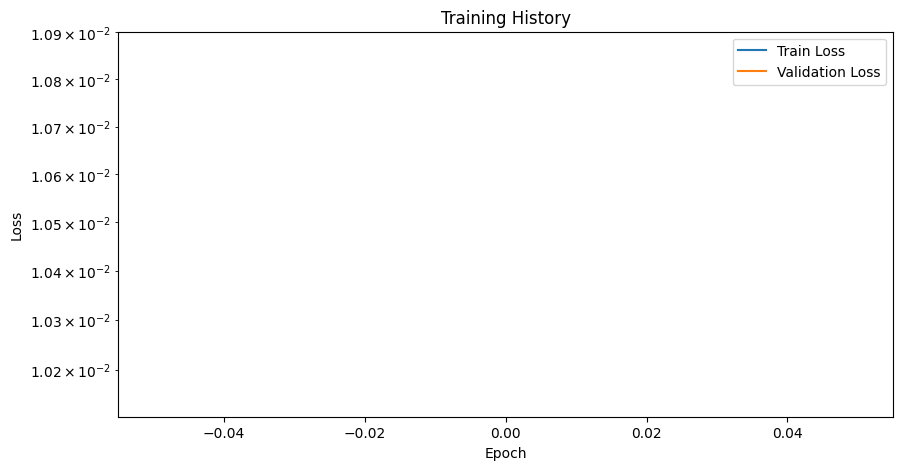

  5%|▌         | 1/20 [01:37<30:47, 97.22s/it]

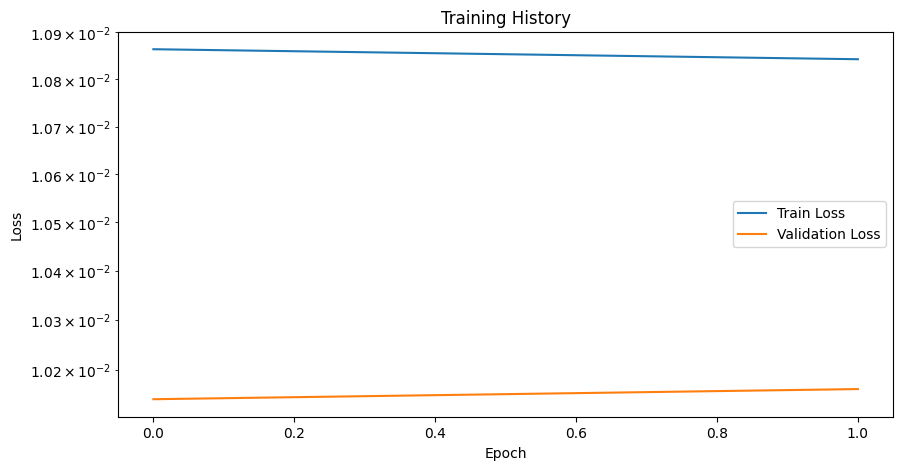

 10%|█         | 2/20 [03:45<34:36, 115.34s/it]

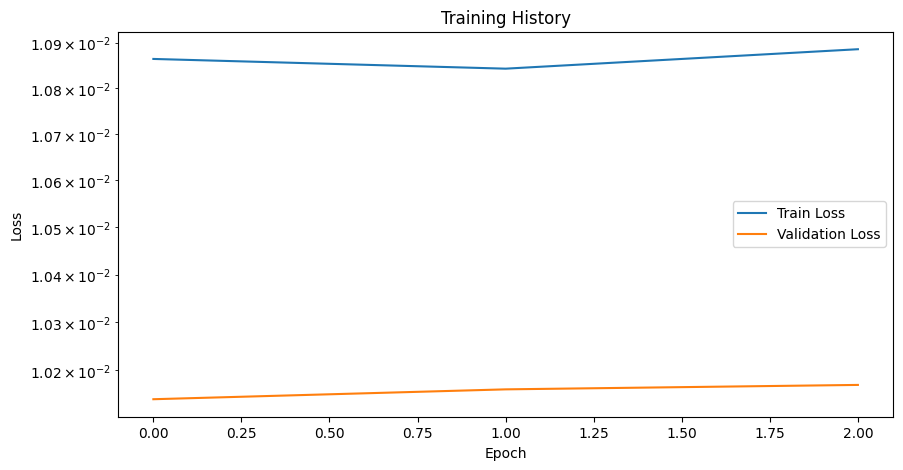

 15%|█▌        | 3/20 [05:22<30:23, 107.26s/it]

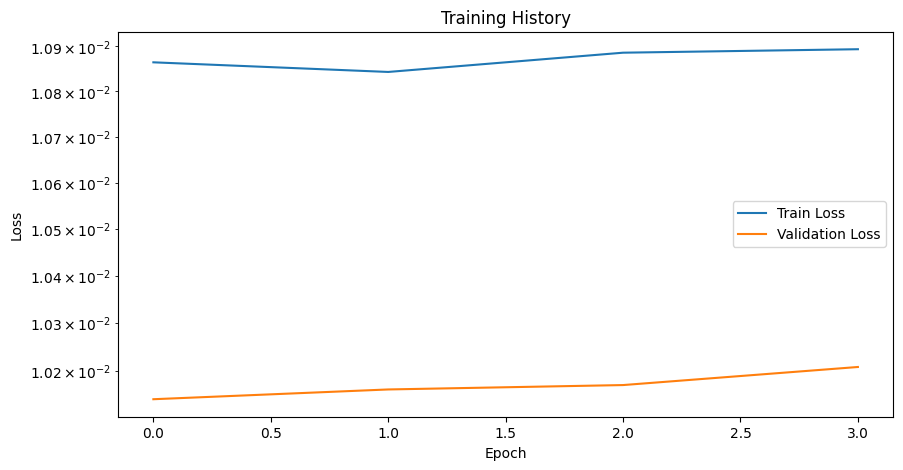

 20%|██        | 4/20 [07:03<27:55, 104.73s/it]

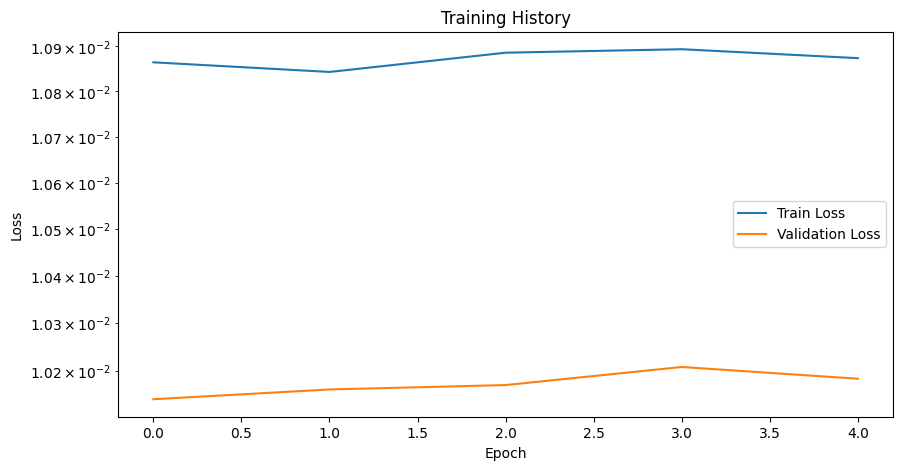

 25%|██▌       | 5/20 [09:19<28:58, 115.91s/it]

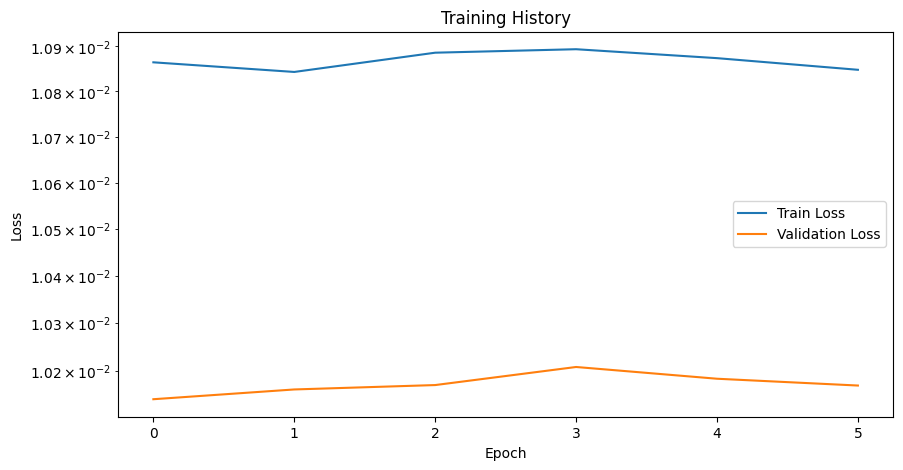

 30%|███       | 6/20 [10:53<25:19, 108.55s/it]

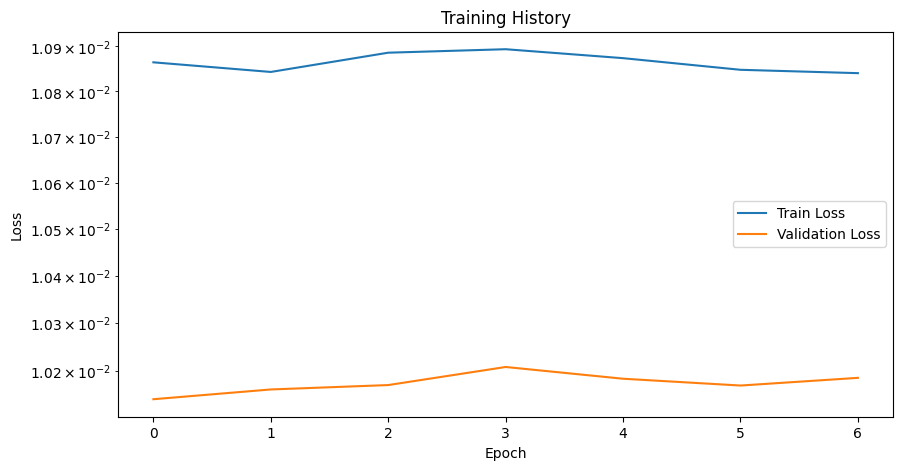

 35%|███▌      | 7/20 [12:35<23:01, 106.28s/it]

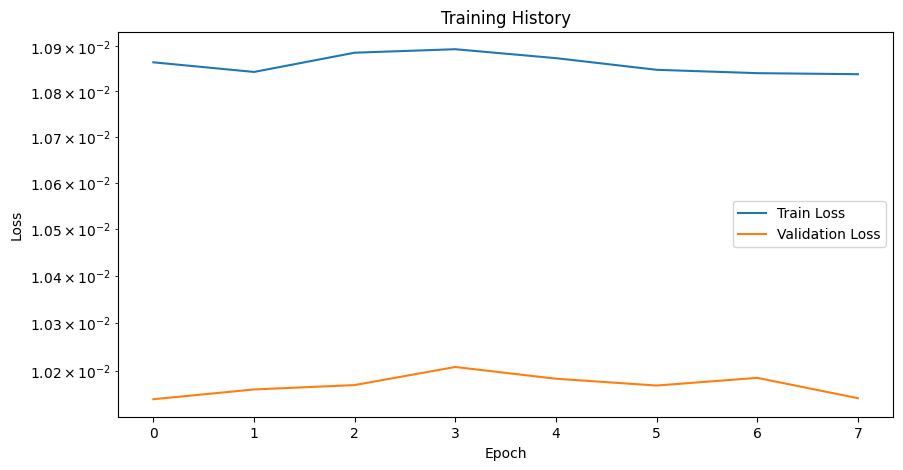

 40%|████      | 8/20 [14:43<22:38, 113.21s/it]

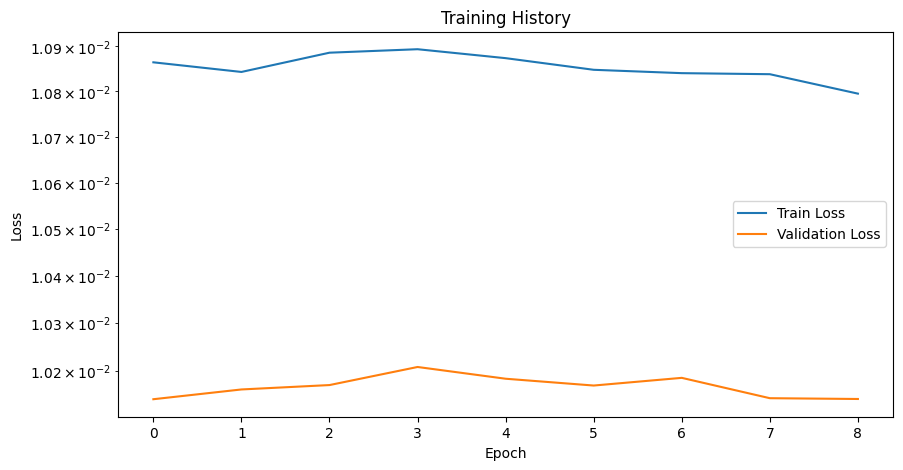

 45%|████▌     | 9/20 [16:15<19:32, 106.63s/it]

Epoch [10/20], Train Loss: 0.010783, Val Loss: 0.010139, LR: 2.50e-04


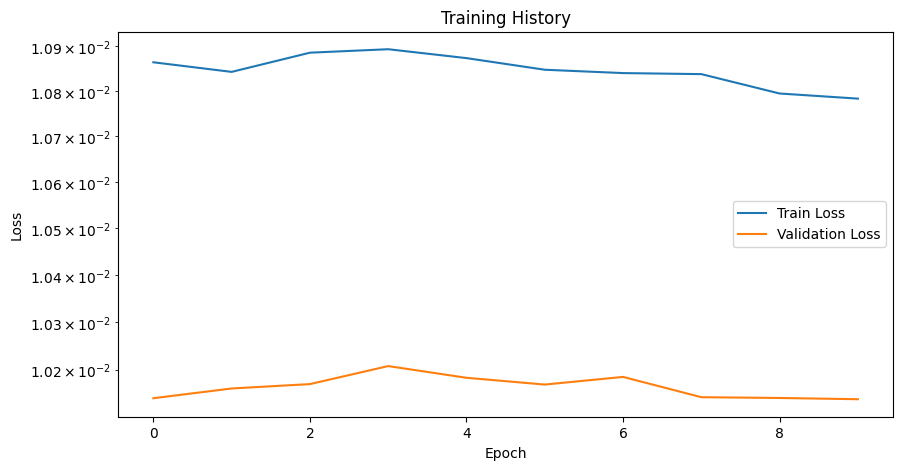

 50%|█████     | 10/20 [17:54<17:22, 104.25s/it]

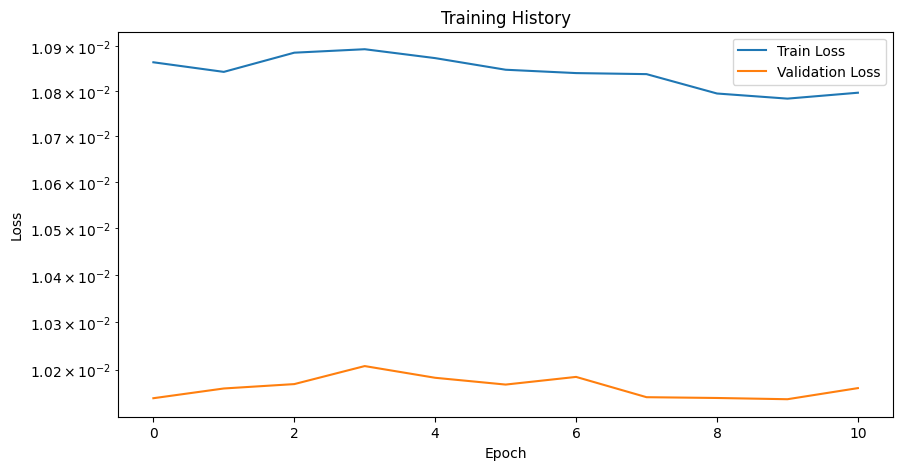

 55%|█████▌    | 11/20 [20:06<16:54, 112.75s/it]

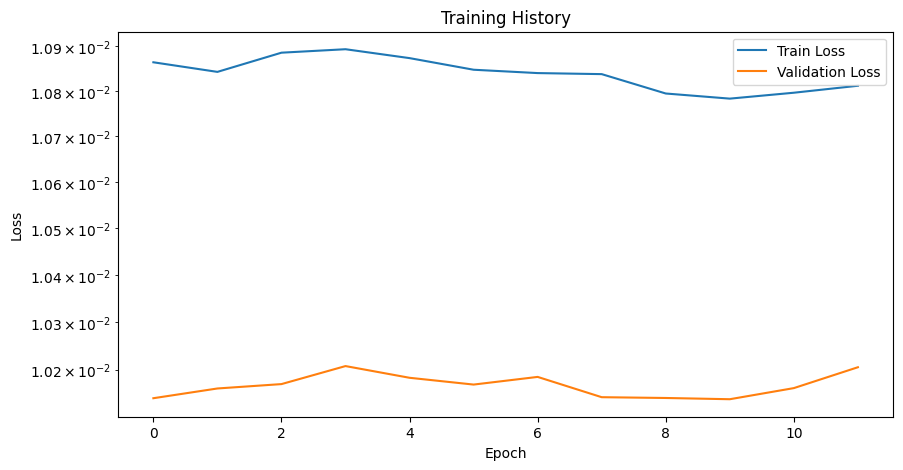

 60%|██████    | 12/20 [21:47<14:34, 109.26s/it]

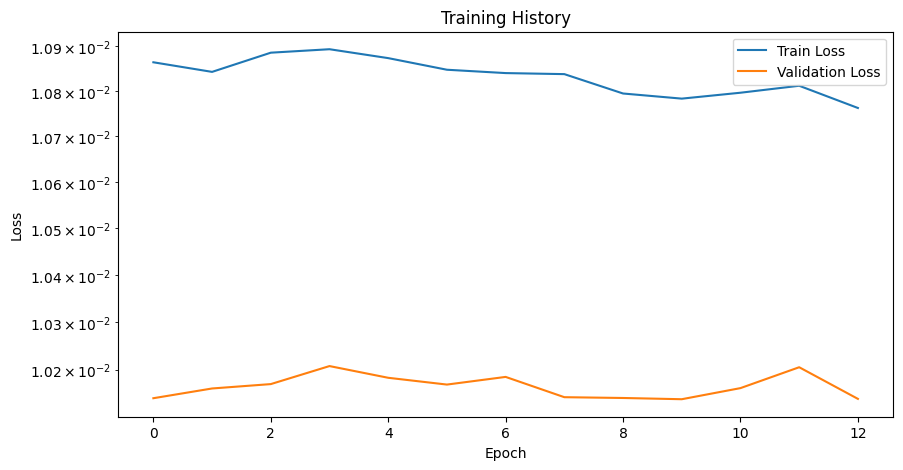

 65%|██████▌   | 13/20 [23:39<12:49, 109.90s/it]

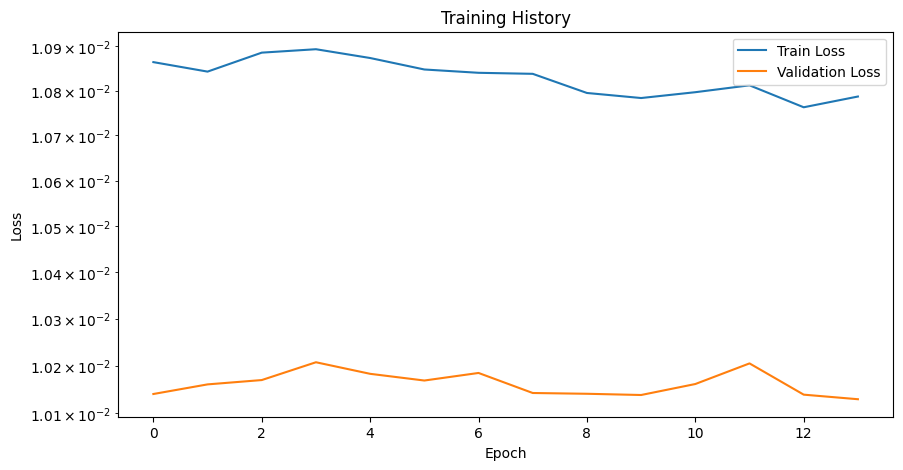

 70%|███████   | 14/20 [26:27<11:20, 113.40s/it]


KeyboardInterrupt: 

In [28]:
# Обучение модели
model, train_losses, val_losses = train_mlp_ensemble(
    model,
    train_data,
    val_data,
    train_y_true,
    val_y_true,
    n_models=7, 
    epochs=20, 
    batch_size=8,
    learning_rate=0.0005
)


In [ ]:
model.eval()

EnhancedEnsemble_3(
  (network): Sequential(
    (0): Conv2d(28, 16, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
    (7): ReLU()
    (8): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Conv2d(16, 4, kernel_size=(1, 1), stride=(1, 1))
  )
)

In [ ]:
metrics(model(test_data.to('cuda:2')).to('cpu'), test_y_true.to('cpu'))

RMSE
layer_0
tensor(0.0183, grad_fn=<CloneBackward0>)
layer_1
tensor(0.0237, grad_fn=<CloneBackward0>)
layer_2
tensor(0.0228, grad_fn=<CloneBackward0>)
layer_3
tensor(0.1980, grad_fn=<CloneBackward0>)
SSIM
layer_0
tensor(0.9951, grad_fn=<MeanBackward0>)
layer_1
tensor(0.9974, grad_fn=<MeanBackward0>)
layer_2
tensor(0.9979, grad_fn=<MeanBackward0>)
layer_3
tensor(0.9812, grad_fn=<MeanBackward0>)
PSNR
layer_0
tensor(50.0791, grad_fn=<MeanBackward0>)
layer_1
tensor(53.4010, grad_fn=<MeanBackward0>)
layer_2
tensor(55.0880, grad_fn=<MeanBackward0>)
layer_3
tensor(44.5366, grad_fn=<MeanBackward0>)


In [5]:
import glob
import os
import torch
import tqdm
import pickle

from hydra import compose, initialize
from cmip6_cmip6_dl_base_model import main

CONFIG_NAME = "cmip6-cmip6"

with initialize(version_base=None, config_path="configs/inference"):
    cfg_inference = compose(config_name=CONFIG_NAME)

with initialize(version_base=None, config_path="configs/train"):
    cfg_train = compose(config_name=CONFIG_NAME)

i = 0,
seed = 42
model = 'unet'

version=0
ckpt_dir = glob.glob(os.path.join(cfg_inference.path, f"{model}_multi_{cfg_inference[model][0].upsampling}_{seed}/logs/version_{version}/checkpoints/"+"epoch_*.*"))
cfg_train["model"].upsampling = cfg_inference[model][0].upsampling
cfg_train.model.architecture = model
cfg_train.training.checkpoint = ckpt_dir[-1]

model_module, dm = main(cfg_train);
model_module.eval().to('cuda:5')
dm.setup()

y_true_train = []
with torch.no_grad():
    for batch in dm.predict_dataloader():
        _, y, _, _ = batch
        y_true_train.append(y)

y_true_val = []
with torch.no_grad():
    for batch in dm.val_dataloader():
        _, y, _, _ = batch
        y_true_val.append(y)

y_true_test = []
with torch.no_grad():
    for batch in dm.test_dataloader():
        _, y, _, _ = batch
        y_true_test.append(y)

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Loading architecture: unet
Using optimizer associated with architecture
Using learning rate scheduler associated with architecture
Loading training loss: mse
No train transform
Loading validation loss: rmse
Loading validation loss: pearson
Loading validation loss: mean_bias
Loading validation loss: mse
Loading validation loss: PSNR
Loading validation loss: SSIM
Loading validation loss: KGE
Loading validation transform: denormalize
Loading validation transform: denormalize
Loading validation transform: denormalize
No validation transform
Loading validation transform: denormalize
Loading validation transform: denormalize
No validation transform
Loading test loss: rmse
Loading test loss: lat_rmse
Loading test loss: pearson
Loading test loss: lat_mean_bias
Loading test loss: mean_bias
Loading test loss: lat_PSNR
Loading test loss: PSNR
Loading test loss: SSIM
Loading test loss: KGE
Loading test transform: denormalize
Loading test transform: denormalize
Loading test transform: denormalize
L

In [15]:
print('saving train')
with open('y_true_train_ens_data.pkl', 'wb') as f:
    pickle.dump(torch.cat(y_true_train), f)
print('done')

print('saving val')
with open('y_true_val_ens_data.pkl', 'wb') as f:
    pickle.dump(torch.cat(y_true_val), f)
print('done')

print('saving test')
with open('y_true_test_ens_data.pkl', 'wb') as f:
    pickle.dump(torch.cat(y_true_test), f)
print('done')

saving train
done
saving val
done
saving test
done
